In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df=pd.read_csv("placement.csv")

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [40]:
df.shape

(200, 2)

In [41]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [42]:
df.sample()

,cgpa,package
165,8.21,4.08


In [43]:
df.isnull().sum()

cgpa       0
package    0
dtype: int64

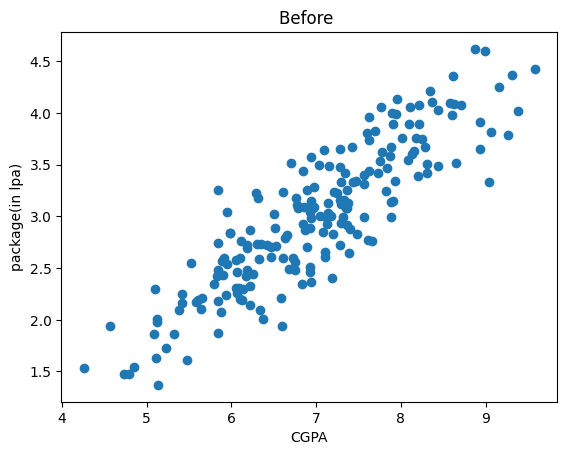

In [44]:
plt.scatter(df["cgpa"],df["package"])
plt.xlabel("CGPA")
plt.ylabel("package(in lpa)")
plt.title("Before ")
plt.show()

In [45]:
x=df.drop(['package'],axis=1)
y=df['package']
#x=df.iloc[:,0:1]
#y=df.iloc[:,-1]

In [46]:
x.head()

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94


In [47]:
x.shape

(200, 1)

In [48]:
y.shape

(200,)

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [50]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [51]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
x_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [53]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [54]:
model.predict(x_test)

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [55]:
model.predict(x_test.iloc[2].values.reshape(1,1))

C:\Users\Harika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.38464568])

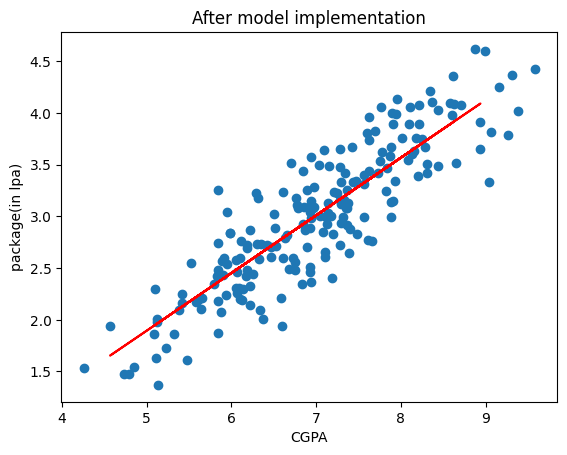

In [56]:
plt.scatter(df["cgpa"],df["package"])
plt.plot(x_test,model.predict(x_test),color='red')
plt.xlabel("CGPA")
plt.ylabel("package(in lpa)")
plt.title("After model implementation")
plt.show()

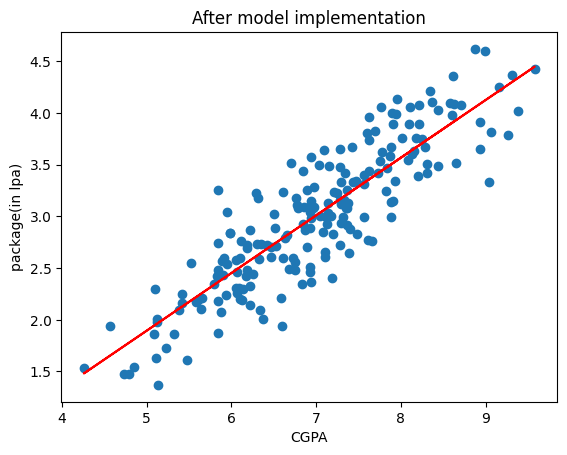

In [57]:
plt.scatter(df["cgpa"],df["package"])
plt.plot(x_train,model.predict(x_train),color='red')
plt.xlabel("CGPA")
plt.ylabel("package(in lpa)")
plt.title("After model implementation")
plt.show()

In [58]:
m= model.coef_ 

In [59]:
b=model.intercept_

In [60]:
m,b

(array([0.55795197]), np.float64(-0.8961119222429144))

In [61]:
y=0.55795197*8.58+ 0.8961119222429144

In [62]:
y

5.683339824842914

In [63]:
m*9.5 +b

array([4.40443183])

In [64]:
m*9.5+b

array([4.40443183])

In [65]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

In [67]:
y_pred=model.predict(x_test)

In [68]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [70]:
print("MAE:",mean_absolute_error(y_test,y_pred))

MAE: 0.2884710931878175


In [71]:
print("MSE:",mean_squared_error(y_test,y_pred))

MSE: 0.12129235313495527


In [72]:
print("RootMeanSquareError:",root_mean_squared_error(y_test,y_pred))

RootMeanSquareError: 0.34827051717731616


In [73]:
print("R2 :",r2_score(y_test,y_pred))

R2 : 0.780730147510384


In [75]:
print("RootMeanSquareError:",np.sqrt(mean_squared_error(y_test,y_pred)))

RootMeanSquareError: 0.34827051717731616


In [76]:
# Adjusted R2 score
x_test.shape

(40, 1)

In [78]:
r2=r2_score(y_test,y_pred)
1-((1-r2)*(40-1)/(40-1-1))

0.9978615843343098

In [79]:
r2

0.780730147510384

In [80]:
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [82]:
new_df1=df.copy()
new_df1['random_feature']=np.random.random(200)
new_df1=new_df1[["cgpa",'random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.385151,3.26
1,5.12,0.015973,1.98
2,7.82,0.557702,3.25
3,7.42,0.995301,3.67
4,6.94,0.134854,3.57


Text(0, 0.5, 'package(in lpa)')

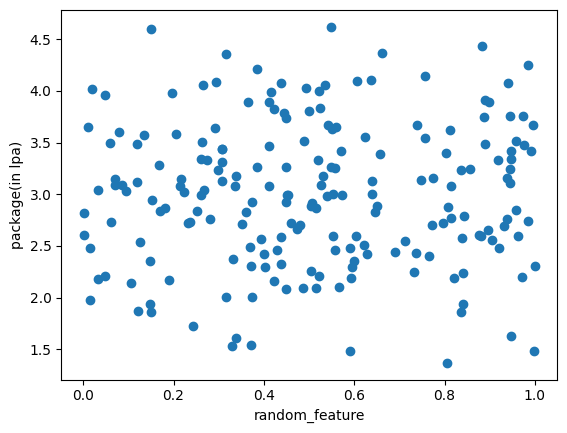

In [83]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel("random_feature")
plt.ylabel("package(in lpa)")
